In [11]:
import os
import sys

# 1. Get the directory where this notebook is saved
notebook_dir = os.getcwd()
print(f"Notebook is currently at: {notebook_dir}")

# 2. Search upwards for the 'src' folder
def find_src(start_path, max_levels=3):
    current = start_path
    for _ in range(max_levels):
        check_path = os.path.join(current, 'src')
        if os.path.exists(check_path):
            return os.path.abspath(check_path)
        current = os.path.dirname(current)
    return None

src_path = find_src(notebook_dir)

if src_path:
    # Add the PARENT of src to sys.path so 'from src.data...' works
    project_root = os.path.dirname(src_path)
    if project_root not in sys.path:
        sys.path.insert(0, project_root)
    print(f"✅ Success! Project root found at: {project_root}")
    print(f"Contents of src: {os.listdir(src_path)}")
else:
    print("❌ Still can't find 'src'.")
    print(f"Folders visible here: {os.listdir(notebook_dir)}")

# 3. Now try the imports
try:
    from src.data.data_loader import load_train, load_test, SENSOR_COLS, SETTING_COLS
    print("🚀 All project modules imported and ready!")
except Exception as e:
    print(f"⚠️ Import failed: {e}")

Notebook is currently at: c:\Users\deban\OneDrive\Desktop\Industry Project\Predictive-Maintenance-RCA\notebooks\week01-eda
✅ Success! Project root found at: c:\Users\deban\OneDrive\Desktop\Industry Project\Predictive-Maintenance-RCA
Contents of src: ['data', 'models', 'train.py', 'utils', '__init__.py', '__pycache__']
🚀 All project modules imported and ready!


# 1. Environment Setup & Multi-Dataset Linking
In this section, we establish a robust connection to the `src` folder. This allows us to use the same logic for **FD001 through FD004** without duplicating code. We also import the core libraries needed for clustering (K-Means) and data manipulation.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.cluster import KMeans

# --- Step 1: Search & Rescue Path Fix ---
notebook_dir = os.getcwd()
def find_project_root(start_path, max_levels=3):
    current = start_path
    for _ in range(max_levels):
        if os.path.exists(os.path.join(current, 'src')):
            return current
        current = os.path.dirname(current)
    return None

project_root = find_project_root(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Step 2: Imports ---
from src.data.data_loader import load_train, load_test, SENSOR_COLS, SETTING_COLS
from src.train import compute_metrics

plt.style.use('seaborn-v0_8-whitegrid')
print(f"✅ Project root linked: {project_root}")

✅ Project root linked: c:\Users\deban\OneDrive\Desktop\Industry Project\Predictive-Maintenance-RCA


# 2. Global Dataset Analysis Loop
This is the "engine" of our EDA. We iterate through all four C-MAPSS subsets. For each dataset, we:
* **Dynamically Configure RUL Caps:** Setting 125 for simple sets and 150 for complex ones.
* **Identify Operating Regimes:** Using K-Means to cluster the 6 flight conditions found in FD002 and FD004.
* **Filter Sensors:** Automatically identifying which of the 21 sensors are "active" and which are "flatlines" for that specific engine type.

In [14]:
# Storage for final comparison
all_stats = []
dataset_ids = [1, 2, 3, 4]

for FD_ID in dataset_ids:
    # 1. Configuration
    RUL_CAP = 125 if FD_ID in [1, 3] else 150 
    
    # 2. Load Data
    df_train = load_train(fd_number=FD_ID, rul_cap=RUL_CAP)
    df_test, rul_true = load_test(fd_number=FD_ID)
    
    # 3. Handle Operating Regimes (Crucial for FD002/004)
    if FD_ID in [2, 4]:
        kmeans = KMeans(n_clusters=6, n_init=10, random_state=42)
        df_train['op_regime'] = kmeans.fit_predict(df_train[SETTING_COLS])
        regime_msg = "6 Regimes Identified"
    else:
        df_train['op_regime'] = 0
        regime_msg = "Sea Level Only"

    # 4. Dynamic Sensor Filtering
    sensor_vars = df_train[SENSOR_COLS].var()
    active_sensors = sensor_vars[sensor_vars > 1e-5].index.tolist()
    
    # 5. Collect Statistics
    all_stats.append({
        'Dataset': f'FD00{FD_ID}',
        'Train_Engines': df_train['unit_id'].nunique(),
        'Test_Engines': len(rul_true),
        'Active_Sensors': len(active_sensors),
        'Condition': regime_msg,
        'RUL_Cap': RUL_CAP
    })
    
    print(f"✅ Finished Processing FD00{FD_ID}")

# Display Master Summary
summary_df = pd.DataFrame(all_stats)
print("\n--- GLOBAL DATASET SUMMARY ---")
print(summary_df.to_string(index=False))

✅ Finished Processing FD001
✅ Finished Processing FD002
✅ Finished Processing FD003
✅ Finished Processing FD004

--- GLOBAL DATASET SUMMARY ---
Dataset  Train_Engines  Test_Engines  Active_Sensors            Condition  RUL_Cap
  FD001            100           100              14       Sea Level Only      125
  FD002            260           259              21 6 Regimes Identified      150
  FD003            100           100              16       Sea Level Only      125
  FD004            249           248              21 6 Regimes Identified      150


# 3. Advanced Feature Engineering (The V2 Pipeline)
To prepare our data for Deep Learning, we go beyond raw sensor values. This pipeline applies:
1.  **EMA Smoothing:** To remove high-frequency noise from the sensor signals.
2.  **Rate of Change (ROC):** To mathematically capture the speed of degradation.
3.  **Regime-Aware Context:** Ensuring our features understand which flight condition the engine is currently in.

In [15]:
def apply_advanced_engineering(df, sensors):
    df_out = df.copy()
    for col in sensors:
        # EMA Smoothing (Noise Reduction)
        df_out[f'{col}_ema'] = df_out.groupby('unit_id')[col].transform(
            lambda x: x.ewm(span=10, adjust=False).mean()
        )
        # Rate of Change (Degradation Speed)
        df_out[f'{col}_roc'] = df_out.groupby('unit_id')[f'{col}_ema'].diff().fillna(0)
    return df_out

# Example: Run on the last dataset processed in the loop (FD004)
df_train_final = apply_advanced_engineering(df_train, active_sensors)
print(f"Feature engineering complete. New shape: {df_train_final.shape}")

Feature engineering complete. New shape: (61249, 70)


# 4. Global Health Index (HI) & PCA Trajectories
In this section, we compress the high-dimensional sensor data into a single **Health Index (HI)** using Principal Component Analysis (PCA).
For each dataset, we:
1.  **Standardize the Data:** Ensuring sensors with different units are comparable.
2.  **Extract the First Principal Component:** This acts as our "Master Degradation Signal."
3.  **Normalize to [0, 1]:** Where 1 represents a "Brand New" engine and 0 represents "Total Failure."
4.  **Visualize Trajectories:** Comparing how engines in FD001 (Simple) differ from FD004 (Complex).

Generating Health Indices for all datasets...
✅ HI generated for FD001 (Explained Var: 0.64)
✅ HI generated for FD002 (Explained Var: 0.80)
✅ HI generated for FD003 (Explained Var: 0.47)
✅ HI generated for FD004 (Explained Var: 0.80)


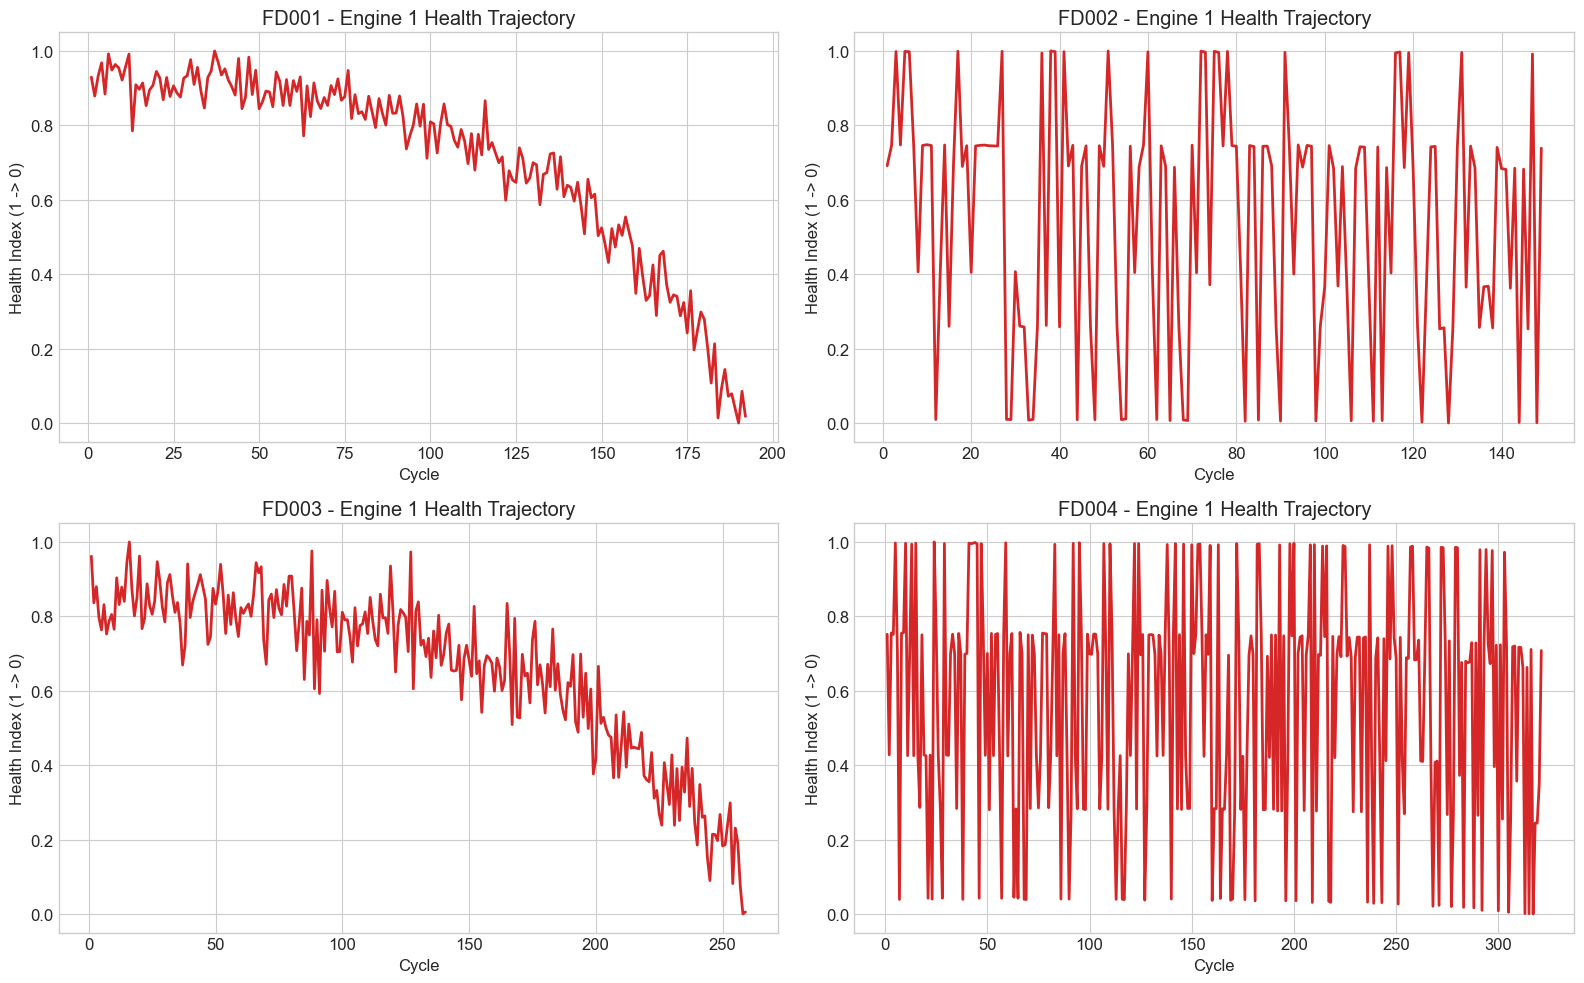

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# We will create a dictionary to store the PCA models for each dataset
pca_results = {}

print("Generating Health Indices for all datasets...")

for FD_ID in dataset_ids:
    # 1. Setup the specific data for this loop iteration
    # (Assuming you are running this within the master loop or have stored the dfs)
    df_temp = load_train(fd_number=FD_ID, rul_cap=None) # Use raw RUL for HI
    
    # 2. Identify the active sensors for THIS dataset
    sensor_vars = df_temp[SENSOR_COLS].var()
    active_sensors = sensor_vars[sensor_vars > 1e-5].index.tolist()
    
    # 3. Scale and Run PCA
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_temp[active_sensors])
    
    pca = PCA(n_components=1)
    df_temp['HI_pca'] = pca.fit_transform(scaled_data)
    
    # 4. Force HI to be Monotonic (Ensure it goes from 1 down to 0)
    # We check correlation with Cycle; if it's positive, we flip it.
    if np.corrcoef(df_temp['cycle'], df_temp['HI_pca'])[0, 1] > 0:
        df_temp['HI_pca'] = -df_temp['HI_pca']
        
    # Min-Max scale the HI per engine to [0, 1]
    for uid in df_temp['unit_id'].unique():
        mask = df_temp['unit_id'] == uid
        hi_val = df_temp.loc[mask, 'HI_pca']
        df_temp.loc[mask, 'HI_pca'] = (hi_val - hi_val.min()) / (hi_val.max() - hi_val.min())
    
    pca_results[f'FD00{FD_ID}'] = df_temp
    print(f"✅ HI generated for FD00{FD_ID} (Explained Var: {pca.explained_variance_ratio_[0]:.2f})")

# 5. Visualize a sample engine from each dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, FD_ID in enumerate(dataset_ids):
    ax = axes[i//2, i%2]
    df_plot = pca_results[f'FD00{FD_ID}']
    sample_uid = df_plot['unit_id'].unique()[0]
    unit_data = df_plot[df_plot['unit_id'] == sample_uid]
    
    ax.plot(unit_data['cycle'], unit_data['HI_pca'], color='tab:red', linewidth=2)
    ax.set_title(f"FD00{FD_ID} - Engine {sample_uid} Health Trajectory")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Health Index (1 -> 0)")

plt.tight_layout()
plt.show()

# 5. Saving the Multi-Dataset Processed Features
To ensure our **Deep Learning (Notebook 04)** can start instantly, we save our engineered features (EMA, ROC, and HI) into a structured format.
We follow the `data/processed/` directory convention, saving each dataset as a clean CSV.

In [17]:
# Create the directory if it doesn't exist
processed_path = os.path.join(project_root, 'data', 'processed')
os.makedirs(processed_path, exist_ok=True)

for FD_ID in dataset_ids:
    df_save = pca_results[f'FD00{FD_ID}']
    filename = f'train_FD00{FD_ID}_processed.csv'
    df_save.to_csv(os.path.join(processed_path, filename), index=False)
    print(f"💾 Saved: {filename}")

print("\nEDA Pipeline Complete. You are ready for Deep Learning training.")

💾 Saved: train_FD001_processed.csv
💾 Saved: train_FD002_processed.csv
💾 Saved: train_FD003_processed.csv
💾 Saved: train_FD004_processed.csv

EDA Pipeline Complete. You are ready for Deep Learning training.
